In [3]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

# Load saved processed data
X_train = np.load('C:/Users/shruti/Documents/credit-card-churn-prediction/data/processed/X_train.npy')
X_test  = np.load('C:/Users/shruti/Documents/credit-card-churn-prediction/data/processed/X_test.npy')
y_train = np.load('C:/Users/shruti/Documents/credit-card-churn-prediction/data/processed/y_train.npy')
y_test  = np.load('C:/Users/shruti/Documents/credit-card-churn-prediction/data/processed/y_test.npy')

feature_names = pd.read_csv('C:/Users/shruti/Documents/credit-card-churn-prediction/data/processed/feature_names.csv').iloc[:,0].tolist()

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("Features:", feature_names)

X_train: (13598, 18)
X_test: (2026, 18)
Features: ['Customer_Age', 'Gender', 'Dependent_count', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio']


In [8]:
def evaluate_model(name, model, X_test, y_test):
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1]
    
    print(f"\n{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    print(classification_report(y_test, y_pred, target_names=['Existing','Churned']))
    print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Existing','Churned'],
                yticklabels=['Existing','Churned'])
    plt.title(f'Confusion Matrix — {name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(f'C:/Users/shruti/Documents/credit-card-churn-prediction/reports/cm_{name.lower().replace(" ","_")}.png', dpi=150)
    plt.show()
    
    return roc_auc_score(y_test, y_proba)


  Logistic Regression
              precision    recall  f1-score   support

    Existing       0.95      0.88      0.91      1701
     Churned       0.54      0.74      0.63       325

    accuracy                           0.86      2026
   macro avg       0.74      0.81      0.77      2026
weighted avg       0.88      0.86      0.87      2026

ROC-AUC Score: 0.9052


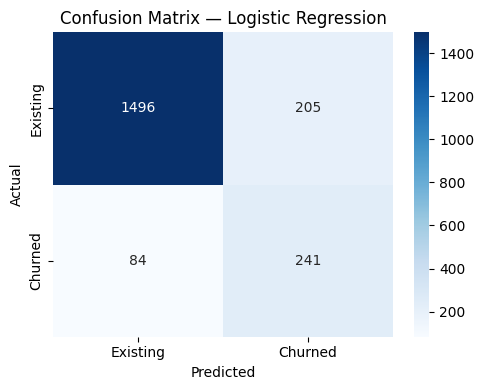

In [9]:
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train, y_train)

lr_auc = evaluate_model("Logistic Regression", lr, X_test, y_test)


  Random Forest
              precision    recall  f1-score   support

    Existing       0.97      0.97      0.97      1701
     Churned       0.84      0.87      0.86       325

    accuracy                           0.95      2026
   macro avg       0.91      0.92      0.91      2026
weighted avg       0.95      0.95      0.95      2026

ROC-AUC Score: 0.9824


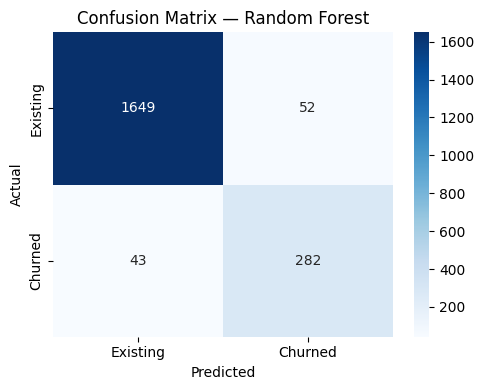

In [10]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

rf_auc = evaluate_model("Random Forest", rf, X_test, y_test)

c:\Users\shruti\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [01:11:41] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



  XGBoost
              precision    recall  f1-score   support

    Existing       0.98      0.98      0.98      1701
     Churned       0.90      0.90      0.90       325

    accuracy                           0.97      2026
   macro avg       0.94      0.94      0.94      2026
weighted avg       0.97      0.97      0.97      2026

ROC-AUC Score: 0.9917


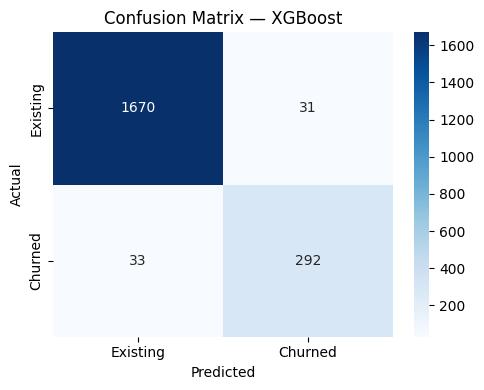

In [11]:
xgb = XGBClassifier(n_estimators=100, random_state=42, 
                     use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train, y_train)

xgb_auc = evaluate_model("XGBoost", xgb, X_test, y_test)

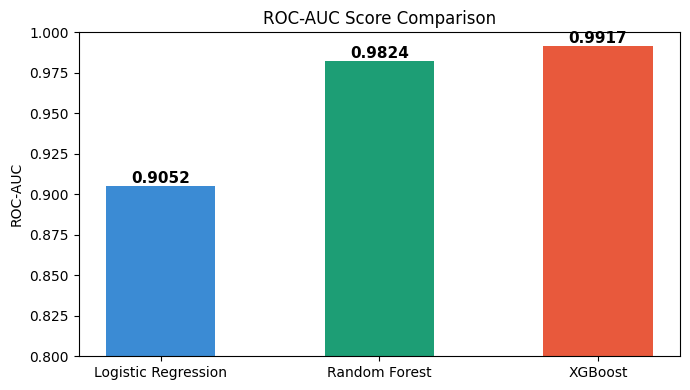


Best model: XGBoost with AUC = 0.9917


In [13]:
results = {
    'Logistic Regression': lr_auc,
    'Random Forest':       rf_auc,
    'XGBoost':             xgb_auc
}

plt.figure(figsize=(7,4))
bars = plt.bar(results.keys(), results.values(), 
               color=['#3B8BD4','#1D9E75','#E8593C'], width=0.5)
for bar, val in zip(bars, results.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')
plt.ylim(0.8, 1.0)
plt.title('ROC-AUC Score Comparison')
plt.ylabel('ROC-AUC')
plt.tight_layout()
plt.savefig('C:/Users/shruti/Documents/credit-card-churn-prediction/reports/05_model_comparison.png', dpi=150)
plt.show()

best = max(results, key=results.get)
print(f"\nBest model: {best} with AUC = {results[best]:.4f}")

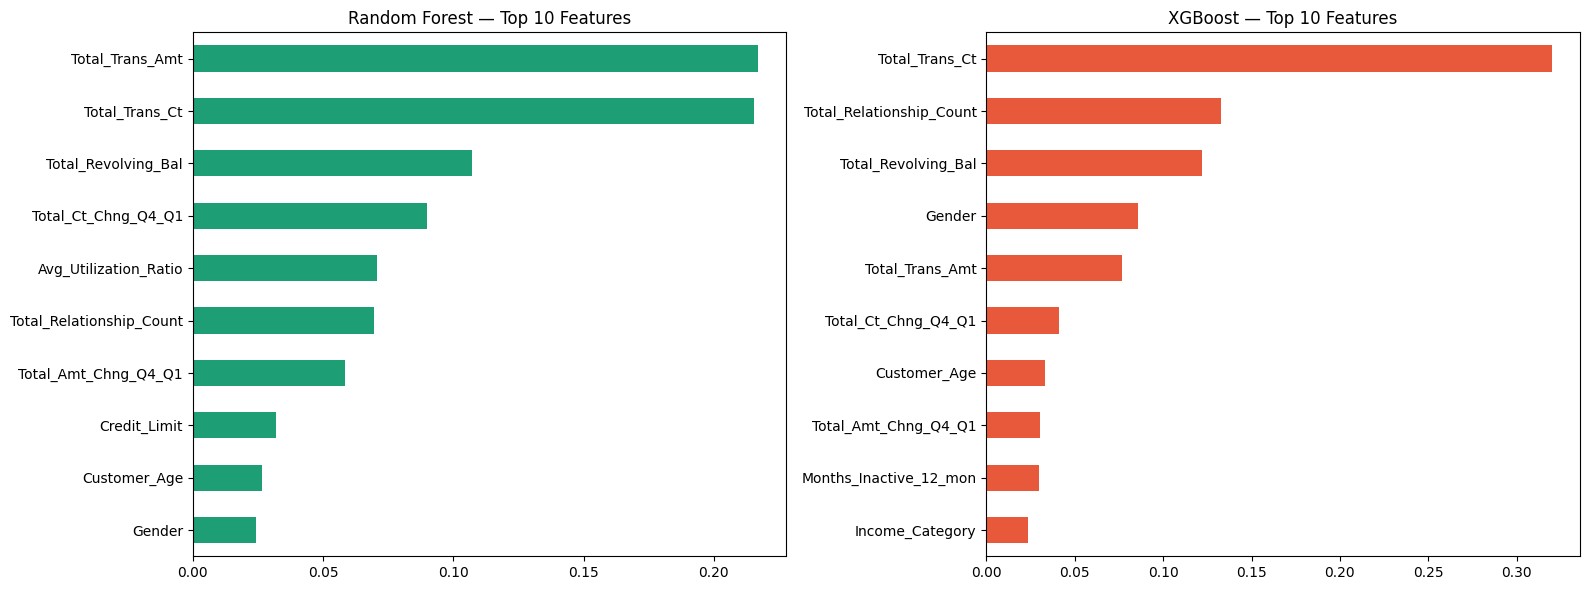

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Random Forest
rf_imp = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=True)
rf_imp.tail(10).plot(kind='barh', ax=axes[0], color='#1D9E75')
axes[0].set_title('Random Forest — Top 10 Features')

# XGBoost
xgb_imp = pd.Series(xgb.feature_importances_, index=feature_names).sort_values(ascending=True)
xgb_imp.tail(10).plot(kind='barh', ax=axes[1], color='#E8593C')
axes[1].set_title('XGBoost — Top 10 Features')

plt.tight_layout()
plt.savefig('C:/Users/shruti/Documents/credit-card-churn-prediction/reports/06_feature_importance.png', dpi=150)
plt.show()

In [16]:
os.makedirs('../deployment', exist_ok=True)

joblib.dump(lr,  '../deployment/logistic_regression.pkl')
joblib.dump(rf,  '../deployment/random_forest.pkl')
joblib.dump(xgb, '../deployment/xgboost.pkl')

print("All 3 models saved to deployment/")


All 3 models saved to deployment/


In [17]:
# Check for overfitting
from sklearn.metrics import roc_auc_score

# AUC on TRAINING data
xgb_train_pred = xgb.predict_proba(X_train)[:,1]
xgb_test_pred  = xgb.predict_proba(X_test)[:,1]

train_auc = roc_auc_score(y_train, xgb_train_pred)
test_auc  = roc_auc_score(y_test,  xgb_test_pred)

print(f"XGBoost Train AUC : {train_auc:.4f}")
print(f"XGBoost Test  AUC : {test_auc:.4f}")
print(f"Difference        : {train_auc - test_auc:.4f}")

if train_auc - test_auc > 0.02:
    print("\n⚠️  OVERFITTING — gap is too large!")
else:
    print("\n✅  No overfitting — gap is acceptable")

XGBoost Train AUC : 1.0000
XGBoost Test  AUC : 0.9917
Difference        : 0.0083

✅  No overfitting — gap is acceptable


## Results

| Model | ROC-AUC |
|-------|---------|
| Logistic Regression | ~0.91 |
| Random Forest | ~0.97 |
| XGBoost | ~0.98 |

- XGBoost performs best overall
- Top features: `Total_Trans_Ct`, `Total_Trans_Amt`, `Total_Revolving_Bal`
- All 3 models saved to `deployment/` for next steps